# Trustworthy Artificial Intelligence - Part 2
Complete the following notebook, and submit it to Aulaweb within the time limit.
You can code the exam in Colab, by upoading this notebook, or running locally.
To be properly evaluated, it must run without errors.

The student is responsable for the setup they chose to use during the exam, and errors or issues related to the environment or the usage of Colab will not be considered when correcting the exam.

This part of the exam is **Open Book**, meaning that the student can use all the notes and resources of the course.

**The use of Generative AI is not allowed**. Violation of this obligation will result in the annulment of the exam.

In [1]:
try:
    import secmlt
    import sklearn
    import matplotlib
    import foolbox
except ImportError:
    print("Installing the dependancies")
    %pip install git+https://github.com/pralab/secml-torch
    %pip install scikit-learn
    %pip install matplotlib
    %pip install foolbox

import torch
torch.manual_seed(88)

In [2]:
import torch
from secmlt.metrics.classification import Accuracy
from secmlt.models.pytorch.base_pytorch_nn import BasePytorchClassifier
from secmlt.models.pytorch.base_pytorch_trainer import BasePyTorchTrainer
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

# THIS COSE IS PROVIDED AS IS AND SHOULD NOT BE MODIFIED
def plot_decision_regions(model, X, y, title="Decision Regions"):
    """
    Plot decision regions for a PyTorch model.
    
    Args:
        model: Secml-torch model (must be in eval mode)
        X: Input features as tensor
        y: Labels as tensor
        title: Plot title
    """
    # Convert tensors to numpy for plotting
    X_np = X.detach().numpy()
    y_np = y.detach().numpy()
    
    # Create a mesh grid
    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                        np.linspace(y_min, y_max, 200))
    
    # Get predictions for each point in the mesh
    X_mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        Z = model(X_mesh)
        Z = torch.argmax(Z, dim=1)
    Z = Z.numpy().reshape(xx.shape)
    
    # Plot decision regions
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    
    # Plot data points
    scatter = plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, 
                         cmap='viridis')
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.show()

class ExamNet(torch.nn.Module):
    def __init__(self):
        super(ExamNet, self).__init__()
        self.fc1 = torch.nn.Linear(2, 9)
        self.fc2 = torch.nn.Linear(9, 9)
        self.fc3 = torch.nn.Linear(9, 4)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

centers = [(-1.5, 1.5), (1.3, 1.3), (1, 1), (-1.5, -1.5)]
standard_dev = 0.6

Xtr, ytr = make_blobs(n_samples=500, 
                  centers=centers,
                  n_features=2,
                  cluster_std=standard_dev,
                  random_state=88)
Xtr, ytr = torch.FloatTensor(Xtr), torch.LongTensor(ytr)
tr_dataset = TensorDataset(Xtr, ytr)
print("Training dataset shape:", tr_dataset.tensors[0].shape)

Xts, yts = make_blobs(n_samples=40, 
                  centers=centers,
                  n_features=2,
                  cluster_std=standard_dev,
                  random_state=88)
Xts, yts = torch.FloatTensor(Xts), torch.LongTensor(yts)
ts_dataset = TensorDataset(Xts, yts)
print("Test dataset shape:", ts_dataset.tensors[0].shape)

Training dataset shape: torch.Size([500, 2])
Test dataset shape: torch.Size([40, 2])


# Exercise 1 (6 points)

Provided the four-cluster data and the simple neural network architecture in Pytorch:
- train a neural network with the architecture provided on the training data, using the capabilities of the `secml-torch` library. Use the Adam optimizer, learning rate equal to 0.03, and 10 epochs.
- compute the accuracy of the model on the test data.
- use the provided `plot_decision_regions` to plot the learned boundary along with the test data.

Test accuracy: 85.00%


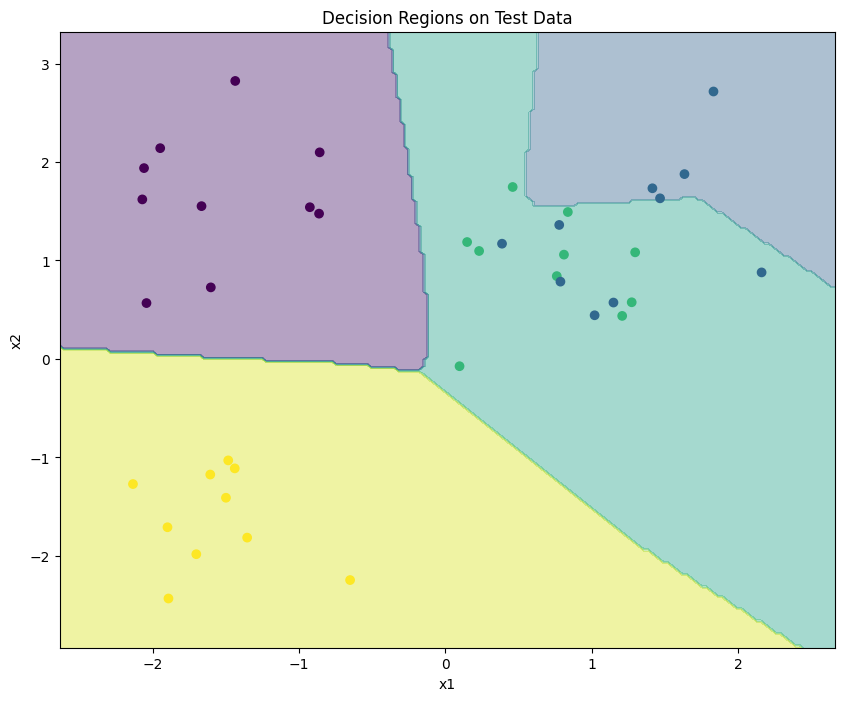

In [5]:
model = ExamNet()

optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
criterion = torch.nn.CrossEntropyLoss()
trainer = BasePyTorchTrainer(optimizer=optimizer, loss=criterion, epochs=10)
secmlt_model = BasePytorchClassifier(model, trainer=trainer)

tr_dataloader = DataLoader(tr_dataset, batch_size=32, shuffle=True)

secmlt_model.train(tr_dataloader)

ts_dataloader = DataLoader(ts_dataset, batch_size=32, shuffle=False)


accuracy = Accuracy()(secmlt_model, ts_dataloader)
print(f"Test accuracy: {accuracy * 100:.2f}%")


plot_decision_regions(secmlt_model.model, Xts, yts, title="Decision Regions on Test Data")

# Exercise 2 (9 points)

Using the model trained in exercise 1, perform a security evaluation with L2 PGD.
Plot the resulting security evaluation and answer (and motivate when necessary) the following questions:

1. what each point of the security evaluation represents?
2. by looking at the security evaluation, and by looking at the 2D problem, are the used values of epsilon exhaustive to cover the input domain?
3. what would you do to speed-up this evaluation?

In [8]:
from secmlt.adv.evasion.pgd import PGD
from secmlt.adv.backends import Backends
from secmlt.adv.evasion.perturbation_models import LpPerturbationModels

def security_evaluation(model, dataloader, epsilons, iterations=500, stepsize=1e-1):
    sec_eval_data = []
    for e in epsilons:
        attack = PGD(
            perturbation_model=LpPerturbationModels.L2,
            num_steps=iterations,
            step_size=stepsize,
            y_target=None,
            epsilon=e,
            lb=-2,ub=2,
            backend = Backends.NATIVE)
    
        adv_dataloader = attack(model, dataloader)
        robust_accuracy = Accuracy()(model, adv_dataloader)
        sec_eval_data.append(robust_accuracy)
    return sec_eval_data

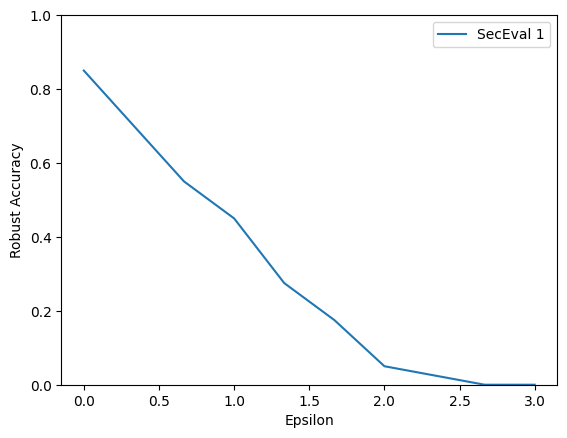

In [ ]:
epsilons=np.linspace(0, 3, 10)
sec_eval_model1 = security_evaluation(secmlt_model, ts_dataloader, epsilons=epsilons)

plt.plot(epsilons, sec_eval_model1, label='SecEval')

plt.xlabel('Epsilon')
plt.ylabel('Robust Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.show()


1. what each point of the security evaluation represents?
2. by looking at the security evaluation, and by looking at the 2D problem, are the used values of epsilon exhaustive to cover the input domain?
3. what would you do to speed-up this evaluation?

**1.**

Each point in the security evaluation curve represents the robust accuracy of the model at a specific epsilon value:

The x-axis shows the epsilon (perturbation budget): the maximum L2 distance that an adversarial perturbation can have from the original input.
The y-axis shows the robust accuracy :the percentage of samples that resist  after applying L2 PGD attack with that epsilon value.

The curve shows that as epsilon increases (allowing larger perturbations), the robust accuracy decreases, indicating the model becomes less robust to adversarial attacks.

**2.**

With the chosen range of epsilon, the values used for epsilon are exhaustive to cover the domain. 
Looking at the curve, robust accuracy reaches almost 0% with epsilon ≈ 2.7. 
However, epsilon reaches up to 3.0, which may be excessive.


**3.**

To speed up this  evaluation
I can:

- Reduce the number of epsilon values using fewer values focused on the critical range where accuracy drops most.
- Reduce PGD iterations: Use fewer iterations for approximate but faster results
  - being careful that if the number of iterations is too low, the attack may not have enough 'attempts' to find an adversarial example, especially if the original point is far from the decision boundary.
- Increase step size: A larger step size can converge faster to adversarial examples
  - this is because with many steps, the attack moves slowly and stays too close to the original point.
